# ET (Einstein Telescope) BNS injection -- PPE (parameterized post-Einsteinian) extension

This notebook is derived from `Final_O5_BNS_Injection_Nested_JIM_NS_AW.ipynb` and adds a
**parameterized post-Einsteinian (PPE)** deformation on top of the GR (IMRPhenomD) waveform,
following Imam & Lagos, *"Tests of scalar polarizations with multi-messenger events"*
(arXiv:2604.24526) -- the same PPE framework originally implemented in the flowMC-based
`jim_v1` repo (`adil3319/jim_v1`), ported here to work with the new nested-sampling
`GW_JAX_TEAM_Nested` repo **without modifying any of that repo's source code**.

What's added, relative to the base O5 notebook:
- A `PPEWaveform` wrapper class (see the "Waveform model" section below) that multiplies the
  GR tensor (+, x) polarizations by an amplitude/phase deformation `(1 + alpha*u^aT)*exp(i*beta*u^b)`,
  and adds a scalar breathing-mode polarization `b` with amplitude `alphaB` -- Eqs. (13)-(19) of
  the paper. It wraps the existing, unmodified `RippleIMRPhenomD_NRTidalv2` waveform.
- Each detector's `polarization_mode` is extended from `"pc"` to `"pcb"` after construction
  (a plain attribute override -- `GroundBased2G.antenna_pattern()` and `Detector.fd_response()`
  are already fully generic over polarization keys, so this is the only detector-side change).
- Three new free parameters -- `alpha`, `beta`, `alphaB` -- added to the prior, sample_transforms,
  injection parameters, and all the post-processing (corner plot, medians/percentiles).

By default the injection uses `alpha = beta = alphaB = 0.0` (a GR-consistent / null test) so you
can first confirm the added machinery recovers zero deviation before injecting an actual
non-GR signal. See the injection-parameters cell for how to inject a genuine deviation instead.


In [1]:
!pip install git+https://github.com/adil1828/GW_JAX_TEAM_Nested

  Cloning https://github.com/adil1828/GW_JAX_TEAM_Nested to /tmp/pip-req-build-8gfku1r1
  Running command git clone --filter=blob:none --quiet https://github.com/adil1828/GW_JAX_TEAM_Nested /tmp/pip-req-build-8gfku1r1
  Resolved https://github.com/adil1828/GW_JAX_TEAM_Nested to commit 6c10db9d7aa3ba82ac0e6cf3b61163f81f584e32
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.3/98.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.7/93.7 kB 11.

In [2]:
import time
#from pathlib import Path

In [3]:
"""GW150914 analysis with the BlackJAX NS-AW nested sampler."""

'GW150914 analysis with the BlackJAX NS-AW nested sampler.'

In [4]:
import corner
import numpy as np
import jax
import jax.numpy as jnp

In [5]:
jax.config.update("jax_enable_x64", True)

In [6]:
!pip install --upgrade "jax[cuda]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html


In [7]:
!pip install ripplegw==0.2.1
from jimgw.core.jim import Jim
from jimgw.core.prior import (
    CombinePrior,
    UniformPrior,
    CosinePrior,
    SinePrior,
    PowerLawPrior,
)
from jimgw.core.prior import GaussianPrior, StandardNormalDistribution
from jimgw.core.single_event.detector import get_ET
from jimgw.core.single_event.likelihood import TransientLikelihoodFD,HeterodynedTransientLikelihoodFD
from jimgw.core.single_event.data import Data
from jimgw.core.single_event.waveform import RippleIMRPhenomXAS_NRTidalv3
from jimgw.core.single_event.transforms import (
    MassRatioToSymmetricMassRatioTransform,
    GeocentricArrivalTimeToDetectorArrivalTimeTransform,
    SkyFrameToDetectorFrameSkyPositionTransform,
)
from jimgw.core.transforms import (
    BoundToBound,
    CosineTransform,
    PowerLawTransform,
    reverse_bijective_transform,
)
from jimgw.samplers.config import BlackJAXNSAWConfig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.6/184.6 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: ripplegw
    Found existing installation: rippleGW 0.3.1
    Uninstalling rippleGW-0.3.1:
      Successfully uninstalled rippleGW-0.3.1


In [8]:
import jimgw
import inspect

print("jimgw version :", jimgw.__version__)
print("jimgw location:", inspect.getfile(jimgw))

jimgw version : 0.0.1.dev11
jimgw location: /usr/local/lib/python3.13/dist-packages/jimgw/__init__.py


In [9]:
import blackjax
import inspect

print("blackjax version :", blackjax.__version__)
print("blackjax location:", inspect.getfile(blackjax))

blackjax version : 1.6.2
blackjax location: /usr/local/lib/python3.13/dist-packages/blackjax/__init__.py


In [10]:
import anesthetic
import inspect

print("anesthetic version :", anesthetic.__version__)
print("anesthetic location:", inspect.getfile(anesthetic))

anesthetic version : 2.15.3
anesthetic location: /usr/local/lib/python3.13/dist-packages/anesthetic/__init__.py


In [11]:
import sys, pkg_resources

packages = [
    "jax", "jaxlib",
    "jax-cuda12-plugin", "jax-cuda12-pjrt",
    "blackjax", "anesthetic", "jimgw",
    "numpy", "scipy"
]

for p in packages:
    try:
        dist = pkg_resources.get_distribution(p)
        print(f"{p}=={dist.version}")
    except Exception:
        print(f"{p}: NOT INSTALLED")

jax==0.11.1
jaxlib==0.11.1
jax-cuda12-plugin==0.11.1
jax-cuda12-pjrt==0.11.1
blackjax==1.6.2
anesthetic==2.15.3
jimgw==0.0.1.dev11
numpy==2.1.3
scipy==1.18.1


/tmp/ipykernel_1728/4177245185.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import sys, pkg_resources


In [12]:
!pip uninstall -y blackjax
!pip install -U "blackjax @ git+https://github.com/blackjax-devs/blackjax.git"

Found existing installation: blackjax 1.6.2
Uninstalling blackjax-1.6.2:
  Successfully uninstalled blackjax-1.6.2
  Cloning https://github.com/blackjax-devs/blackjax.git to /tmp/pip-install-kmhfcmtm/blackjax_b4abe2ead9bd4708a14815e1d6055fc6
  Running command git clone --filter=blob:none --quiet https://github.com/blackjax-devs/blackjax.git /tmp/pip-install-kmhfcmtm/blackjax_b4abe2ead9bd4708a14815e1d6055fc6
  Resolved https://github.com/blackjax-devs/blackjax.git to commit 62d7cb717f454cefea009fdb64b9d1c1082a0b15
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for blackjax: filename=blackjax-1.6.3.dev23+g62d7cb717-py3-none-any.whl size=4962542 sha256=079e076364b6d7043e5a400831d6596ef0c314fe4ca1ae4a0310201d37ad68f8
  Stored in directory: /tmp/pip-ephem-wheel-cache-d8hv9_2k/wheels/f6/03/99/546e9a56ab29fb0c0525631baaad78ed483e63cec4f147c597
Successfully built blackjax


In [13]:
import jax, jaxlib, blackjax
print("jax", jax.__version__)
print("jaxlib", jaxlib.__version__)
print("blackjax", blackjax.__version__)
print(jax.devices())

jax 0.11.1
jaxlib 0.11.1
blackjax 1.6.2
[CudaDevice(id=0)]


In [14]:
import blackjax

print(blackjax.__version__)
print(hasattr(blackjax, "ns"))


1.6.2
True


In [15]:
# q_inj = 0.8
# eta_inj = q_inj / (1.0 + q_inj)**2

inj_params = {
    "M_c": 1.1975174,
    "eta": 0.2379,

    "s1_z": 0.028327,
    "s2_z": 0.013249,

    "d_L": 100.0,

    "t_c": -2.36e-4,
    "phase_c": 2.0,

    "iota": 2.62,
    "psi": 3.14,

    "ra": 3.4396,
    "dec": -0.3998,
    'lambda_1': 791.04366468,
    'lambda_2': 891.04366468,
    # --- PPE (non-GR) parameters, see Imam & Lagos (arXiv:2604.24526) Table I ---
    # Set to 0.0 for a GR-consistent injection (this is a recovery/null test by
    # default). To inject a genuine deviation instead, try e.g.
    # alpha=-5e-3, beta=5e-7, alphaB=-10.0 and re-run the injection + sampling cells.
    "alpha": 0.0,
    "beta": 0.0,
    "alphaB": 0.0,
}


In [16]:
# NOTE: no custom detector-geometry helper needed for ET.
# get_ET() (imported above) already returns a list[GroundBased2G] of all
# three co-located ET interferometers (ET1, ET2, ET3, triangle, 60-degree
# arm-orientation offsets) -- it's already iterable, don't wrap it in
# another [...]. This mirrors the get_CE2() helper this cell used to hold
# for the 2CE version of this notebook, which is not needed here.


In [17]:
# Injection GPS time; choose arbitrary fixed time
gps = 1187008882.43 #GW170817

# M_c ~ 1.2 Msun needs ~160s in-band from fmin=20Hz -- too long for a fast NS
# check. Raising fmin to 40Hz shortens the chirp to ~25.6s, which fits inside
# a 32s window (duration - post_trigger_duration = 30s available), giving
# ~15% margin so the injected data stays self-consistent with the window.
duration = 8192.0
post_trigger_duration = 2.0
start = gps + post_trigger_duration - duration
end = start + duration

psd_duration = 2048.0
psd_start = start - psd_duration
psd_end = start

fmin = 5.0
fmax = 2048.0

ifos = get_ET()  # already a list of 3 GroundBased2G (ET1/ET2/ET3) -- do not wrap in [...]
# --- PPE addition: add the scalar breathing-mode ("b") polarization to each
# detector's antenna pattern, on top of the existing tensor (+, x) modes.
# GroundBased2G.antenna_pattern() and Detector.fd_response() in
# GW_JAX_TEAM_Nested are already fully generic over `polarization_mode` (they
# loop over whatever Polarization objects are present and tree_map/sum over
# matching dict keys), so overriding this one attribute after construction is
# the *only* detector-side change needed -- no jimgw source files are touched.
from jimgw.core.single_event.polarization import Polarization
for ifo in ifos:
    ifo.polarization_mode = [Polarization(m) for m in "pcb"]


In [18]:
# --- PPE (parameterized post-Einsteinian) waveform wrapper ---
# Implements Imam & Lagos (arXiv:2604.24526) Eqs. (13)-(19): tensor amplitude/phase
# deformation (alpha, beta) plus a scalar breathing-mode polarization (alphaB),
# built as a thin wrapper around the *unmodified* RippleIMRPhenomXAS_NRTidalv3 waveform
# already shipped in GW_JAX_TEAM_Nested. No jimgw source files are touched --
# this mirrors the monkeypatch-at-notebook-level pattern used elsewhere in this
# project (e.g. the compute_coefficients / jnp.isin OOM patches).
import jax
import jax.numpy as jnp
from jimgw.core.single_event.waveform import RippleIMRPhenomXAS_NRTidalv3

# The l=m=1 (dipole) breathing-mode envelope needs its own from-scratch PN
# amplitude/phase construction -- it is NOT obtainable by post-processing the
# packaged ripplegw quadrupole output (different overall PN normalization and
# frequency scaling, confirmed by diffing the old jim_v1 repo's
# waveform_l=m=1_final.py against its l=m=2 sibling waveform.py). These are
# genuine external ripplegw utilities (same package GW_JAX_TEAM_Nested already
# depends on for its own RippleIMRPhenomXAS_NRTidalv3) -- importing them here does not
# touch any jimgw source file.
from ripplegw.waveforms.IMRPhenomD_utils import (
    get_coeffs,
    get_delta0,
    get_delta1,
    get_delta2,
    get_delta3,
    get_delta4,
    get_transition_frequencies,
)
from ripplegw.waveforms.IMRPhenomD_QNMdata import fM_CUT
# Mc_eta_to_ms hand-defined locally, not imported -- same version-drift issue
# as EulerGamma/gt/m_per_Mpc/C/PI above (ripplegw>=0.2.1 is an open lower-bound
# pin, so this symbol isn't guaranteed importable from whatever version pip
# resolves). Confirmed live: "ImportError: cannot import name 'Mc_eta_to_ms'
# from 'ripplegw'" in a Colab session with the exact same version of ripplegw
# that raised the earlier EulerGamma ImportError. This is ripplegw's own
# current formula (confirmed from its GitHub source), not an approximation:
# m1 is always returned as the larger mass, m2 the smaller (by construction
# of the +/- sqrt roots), matching the m1>=m2 convention get_coeffs expects.
def Mc_eta_to_ms(m):
    r"""Converts chirp mass and symmetric mass ratio to binary component masses."""
    Mchirp, eta = m
    M = Mchirp / (eta ** (3 / 5))
    m2 = (M - jnp.sqrt(M**2 - 4 * M**2 * eta)) / 2
    m1 = M - m2
    return m1, m2

# NOTE: EulerGamma/gt/m_per_Mpc/C/PI are defined locally rather than imported
# from ripplegw.constants. That module's contents have drifted across
# ripplegw releases (the new repo pins ripplegw>=0.2.1, an open lower bound,
# so whatever version pip resolves at install time isn't guaranteed to expose
# the same names) -- this hit in practice as
# "ImportError: cannot import name 'EulerGamma' from 'ripplegw.constants'"
# in a live Colab run. These are universal physical/mathematical constants,
# not ripple-specific algorithms, so defining them locally (matching
# ripplegw's own current values exactly) removes the dependency entirely and
# makes this cell immune to that kind of drift. get_coeffs/get_delta0-4/
# get_transition_frequencies/fM_CUT/Mc_eta_to_ms above are genuine algorithm
# implementations we can't hand-roll, so those remain real ripplegw imports.
EulerGamma = 0.5772156649015329        # Euler-Mascheroni constant
C = 299792458.0                        # speed of light, m/s (exact, SI)
_G = 6.6743e-11                        # Newton's gravitational constant, m^3 kg^-1 s^-2
_MSUN = 1.988409902147041637325262574352366540e30  # kg (matches ripplegw's own value)
gt = _G * _MSUN / C ** 3.0             # GM_sun/c^3, seconds (== GM_SUN_OVER_C3 below)
m_per_Mpc = 3.085677581491367278913937957796471611e22  # meters per Mpc
PI = jnp.pi

GM_SUN_OVER_C3 = 4.925490947641267e-6  # seconds; solar mass in geometric units (GM_sun/c^3)


# ============================================================================
# Dipole (l=m=1) breathing-mode PN envelope -- ported verbatim from the old
# jim_v1 repo's `waveform_l=m=1_final.py` (the file the user identified as the
# correct reference for the l=m=1 case). Three helper functions
# (`get_IIb_raw_phase`, `get_inspiral_Amp`, `get_IIb_Amp`, all UNsuffixed) are
# cross-referenced internally by this generator (for matching the region
# boundaries / the t=0 phase alignment) and were confirmed, by diffing against
# `waveform_l=m=1_final.py`'s own copies, to be byte-identical to the standard
# l=m=2 IMRPhenomD formulas -- i.e. they are the same functions the l=m=2 case
# uses, just not otherwise needed here since the l=m=2 tensor/breathing output
# is already obtained from the unmodified `RippleIMRPhenomXAS_NRTidalv3` below. They are
# ported here only because `_gen_IMRPhenomD_lm_1` needs them by name.
# ============================================================================

def get_IIb_raw_phase(fM_s, theta, coeffs, f_RD, f_damp):
    m1, m2, _, _ = theta
    m1_s = m1 * gt
    m2_s = m2 * gt
    M_s = m1_s + m2_s
    eta = m1_s * m2_s / (M_s ** 2.0)

    f_RDM_s = f_RD * M_s
    f_dampM_s = f_damp * M_s

    phi_IIb_raw = (
        coeffs[14] * fM_s
        - coeffs[15] * (fM_s ** -1.0)
        + 4.0 * coeffs[16] * (fM_s ** (3.0 / 4.0)) / 3.0
        + coeffs[17] * jnp.arctan((fM_s - coeffs[18] * f_RDM_s) / f_dampM_s)
    ) / eta

    return phi_IIb_raw







def get_IIb_Amp(fM_s, theta, coeffs, f_RD, f_damp):
    m1, m2, _, _ = theta
    m1_s = m1 * gt
    m2_s = m2 * gt
    M_s = m1_s + m2_s
    gamma1 = coeffs[4]
    gamma2 = coeffs[5]
    gamma3 = coeffs[6]
    fDM = f_damp * M_s
    fRD = f_RD * M_s

    fDMgamma3 = fDM * gamma3
    fminfRD = fM_s - fRD
    Amp_IIb = (
        jnp.exp(-(fminfRD) * gamma2 / (fDMgamma3))
        * (fDMgamma3 * gamma1)
        / ((fminfRD) ** 2.0 + (fDMgamma3) ** 2.0)
    )
    return Amp_IIb


def get_inspiral_phase_lm_1(fM_s, theta, coeffs):
    m1, m2, chi1, chi2 = theta
    m1_s = m1 * gt
    m2_s = m2 * gt
    M_s = m1_s + m2_s
    eta = m1_s * m2_s / (M_s ** 2.0)

    m1M = m1_s / M_s
    m2M = m2_s / M_s

    phi0 = 1.0
    phi1 = 0.0
    phi2 = 5.0 * (74.3 / 8.4 + 11.0 * eta) / 9.0
    phi3 = -16.0 * PI + (
        m1M * (25.0 + 38.0 / 3.0 * m1M) * chi1 + m2M * (25.0 + 38.0 / 3.0 * m2M) * chi2
    )
    phi4 = 5.0 * (3058.673 / 7.056 + 5429.0 / 7.0 * eta + 617.0 * eta * eta) / 72.0
    phi4 += (
        (247.0 / 4.8 * eta) * chi1 * chi2
        + (-721.0 / 4.8 * eta) * chi1 * chi2
        + ((-720.0 / 9.6 * m1M * m1M) + (1.0 / 9.6 * m1M * m1M)) * chi1 * chi1
        + ((-720.0 / 9.6 * m2M * m2M) + (1.0 / 9.6 * m2M * m2M)) * chi2 * chi2
        + ((240.0 / 9.6 * m1M * m1M) + (-7.0 / 9.6 * m1M * m1M)) * chi1 * chi1
        + ((240.0 / 9.6 * m2M * m2M) + (-7.0 / 9.6 * m2M * m2M)) * chi2 * chi2
    )
    phi5 = 5.0 / 9.0 * (772.9 / 8.4 - 13.0 * eta) * PI
    phi5 += (
        -m1M * (1391.5 / 8.4 - m1M * (1.0 - m1M) * 10.0 / 3.0 + m1M * (1276.0 / 8.1 + m1M * (1.0 - m1M) * 170.0 / 9.0))
    ) * chi1 + (
        -m2M * (1391.5 / 8.4 - m2M * (1.0 - m2M) * 10.0 / 3.0 + m2M * (1276.0 / 8.1 + m2M * (1.0 - m2M) * 170.0 / 9.0))
    ) * chi2
    phi5_log = (5.0 / 3.0) * (772.9 / 8.4 - 13.0 * eta) * PI
    phi5_log += 3.0 * (
        (
            -m1M * (1391.5 / 8.4 - m1M * (1.0 - m1M) * 10.0 / 3.0 + m1M * (1276.0 / 8.1 + m1M * (1.0 - m1M) * 170.0 / 9.0))
        ) * chi1
        + (
            -m2M * (1391.5 / 8.4 - m2M * (1.0 - m2M) * 10.0 / 3.0 + m2M * (1276.0 / 8.1 + m2M * (1.0 - m2M) * 170.0 / 9.0))
        ) * chi2
    )

    phi6 = (
        (11583.231236531 / 4.694215680 - 640.0 / 3.0 * PI * PI - 684.8 / 2.1 * EulerGamma)
        + eta * (-15737.765635 / 3.048192 + 225.5 / 1.2 * PI * PI)
        + eta * eta * 76.055 / 1.728
        - eta * eta * eta * 127.825 / 1.296
        + (-684.8 / 2.1) * jnp.log(4.0)
    )
    phi6 += (PI * m1M * (1490.0 / 3.0 + m1M * 260.0)) * chi1 + (PI * m2M * (1490.0 / 3.0 + m2M * 260.0)) * chi2
    phi6_log = -684.8 / 2.1

    phi7 = PI * (770.96675 / 2.54016 + 378.515 / 1.512 * eta - 740.45 / 7.56 * eta * eta)
    phi7 += (
        m1M * (
            -17097.8035 / 4.8384 + eta * 28764.25 / 6.72 + eta * eta * 47.35 / 1.44
            + m1M * (-7189.233785 / 1.524096 + eta * 458.555 / 3.024 - eta * eta * 534.5 / 7.2)
        )
    ) * chi1 + (
        m2M * (
            -17097.8035 / 4.8384 + eta * 28764.25 / 6.72 + eta * eta * 47.35 / 1.44
            + m2M * (-7189.233785 / 1.524096 + eta * 458.555 / 3.024 - eta * eta * 534.5 / 7.2)
        )
    ) * chi2

    # Add frequency dependence here -- l=m=1: 2*pi*fM_s (vs. l=m=2's pi*fM_s),
    # and overall normalization 3/(256 eta) (vs. l=m=2's 3/(128 eta)).
    v = (2.0 * PI * fM_s) ** (1.0 / 3.0)

    phi_TF2 = (
        phi0 * ((2.0 * PI * fM_s) ** -(5.0 / 3.0))
        + phi1 * ((2.0 * PI * fM_s) ** -(4.0 / 3.0))
        + phi2 * ((2.0 * PI * fM_s) ** -1.0)
        + phi3 * ((2.0 * PI * fM_s) ** -(2.0 / 3.0))
        + phi4 * ((2.0 * PI * fM_s) ** -(1.0 / 3.0))
        + phi5_log * jnp.log(v)
        + phi5
        + phi6_log * jnp.log(v) * ((2.0 * PI * fM_s) ** (1.0 / 3.0))
        + phi6 * ((2.0 * PI * fM_s) ** (1.0 / 3.0))
        + phi7 * ((2.0 * PI * fM_s) ** (2.0 / 3.0))
    ) * (3.0 / (256.0 * eta)) - PI / 4.0
    phi_Ins = (
        phi_TF2
        + (
            coeffs[7] * fM_s
            + (3.0 / 4.0) * coeffs[8] * (fM_s ** (4.0 / 3.0))
            + (3.0 / 5.0) * coeffs[9] * (fM_s ** (5.0 / 3.0))
            + (1.0 / 2.0) * coeffs[10] * (fM_s ** 2.0)
        )
        / eta
    )
    return phi_Ins


def get_IIa_raw_phase_lm_1(fM_s, theta, coeffs):
    m1, m2, _, _ = theta
    m1_s = m1 * gt
    m2_s = m2 * gt
    M_s = m1_s + m2_s
    eta = m1_s * m2_s / (M_s ** 2.0)

    phi_IIa_raw = (
        coeffs[11] * fM_s + coeffs[12] * jnp.log(fM_s) - coeffs[13] * (fM_s ** -3.0) / 3.0
    ) / eta
    return phi_IIa_raw


def get_IIb_raw_phase_lm_1(fM_s, theta, coeffs, f_RD, f_damp):
    m1, m2, _, _ = theta
    m1_s = m1 * gt
    m2_s = m2 * gt
    M_s = m1_s + m2_s
    eta = m1_s * m2_s / (M_s ** 2.0)

    f_RDM_s = f_RD * M_s
    f_dampM_s = f_damp * M_s

    phi_IIb_raw = (
        coeffs[14] * fM_s
        - coeffs[15] * (fM_s ** -1.0)
        + 4.0 * coeffs[16] * (fM_s ** (3.0 / 4.0)) / 3.0
        + coeffs[17] * jnp.arctan((fM_s - coeffs[18] * f_RDM_s) / f_dampM_s)
    ) / eta
    return phi_IIb_raw


def get_Amp0_lm_1(fM_s, eta):
    # l=m=1 normalization: (4 eta / 3 pi)^0.5 * fM_s^(-9/6) (vs. l=m=2's
    # (2 eta/3)^0.5 * fM_s^(-7/6) * pi^(-1/6)).
    Amp0 = (4.0 * eta / (3.0 * PI)) ** (1.0 / 2.0) * (fM_s) ** (-9.0 / 6.0)
    return Amp0


def get_inspiral_Amp_lm_1(fM_s, theta, coeffs):
    m1, m2, chi1, chi2 = theta
    m1_s = m1 * gt
    m2_s = m2 * gt
    M_s = m1_s + m2_s
    eta = m1_s * m2_s / (M_s ** 2.0)
    eta2 = eta * eta
    eta3 = eta * eta2

    Seta = jnp.sqrt(1.0 - 4.0 * eta)
    SetaPlus1 = 1.0 + Seta

    chi12 = chi1 * chi1
    chi22 = chi2 * chi2

    A0 = 1.0
    A2 = ((-969.0 + 1804.0 * eta) * PI ** (2.0 / 3.0)) / 672.0
    A3 = (
        (chi1 * (81.0 * SetaPlus1 - 44.0 * eta) + chi2 * (81.0 - 81.0 * Seta - 44.0 * eta))
        * PI
    ) / 48.0
    A4 = (
        (
            -27312085.0
            - 10287648.0 * chi22
            - 10287648.0 * chi12 * SetaPlus1
            + 10287648.0 * chi22 * Seta
            + 24.0 * (-1975055.0 + 857304.0 * chi12 - 994896.0 * chi1 * chi2 + 857304.0 * chi22) * eta
            + 35371056.0 * eta2
        )
        * (PI ** (4.0 / 3.0))
    ) / 8.128512e6
    A5 = (
        (PI ** (5.0 / 3.0))
        * (
            chi2 * (-285197.0 * (-1 + Seta) + 4 * (-91902.0 + 1579.0 * Seta) * eta - 35632.0 * eta2)
            + chi1 * (285197.0 * SetaPlus1 - 4.0 * (91902.0 + 1579.0 * Seta) * eta - 35632.0 * eta2)
            + 42840.0 * (-1.0 + 4.0 * eta) * PI
        )
    ) / 32256.0
    A6 = (
        -(
            (PI ** 2.0)
            * (
                -336.0 * (-3248849057.0 + 2943675504.0 * chi12 - 3339284256.0 * chi1 * chi2 + 2943675504.0 * chi22) * eta2
                - 324322727232.0 * eta3
                - 7.0 * (
                    -177520268561.0
                    + 107414046432.0 * chi22
                    + 107414046432.0 * chi12 * SetaPlus1
                    - 107414046432.0 * chi22 * Seta
                    + 11087290368.0 * (chi1 + chi2 + chi1 * Seta - chi2 * Seta) * PI
                )
                + 12.0 * eta * (
                    -545384828789.0
                    - 176491177632.0 * chi1 * chi2
                    + 202603761360.0 * chi22
                    + 77616.0 * chi12 * (2610335.0 + 995766.0 * Seta)
                    - 77287373856.0 * chi22 * Seta
                    + 5841690624.0 * (chi1 + chi2) * PI
                    + 21384760320.0 * (PI ** 2.0)
                )
            )
        )
        / 6.0085960704e10
    )
    A7 = coeffs[0]
    A8 = coeffs[1]
    A9 = coeffs[2]

    # l=m=1: PN inspiral amplitude terms use 2*fM_s (vs. l=m=2's fM_s); A1 and
    # the A7-A9 (3.5PN+) terms are dropped, matching the reference file exactly.

    Amp_Ins = (
        A0
        + A2 * ((2.0 * fM_s) ** (2.0 / 3.0))
        + A3 * (2.0 * fM_s)
        + A4 * ((2.0 * fM_s) ** (4.0 / 3.0))
        + A5 * ((2.0 * fM_s) ** (5.0 / 3.0))
        + A6 * ((2.0 * fM_s) ** 2.0)
    )
    return Amp_Ins








def get_IIa_Amp_lm_1(fM_s, theta, coeffs, f1, f3, f_RD, f_damp):
    m1, m2, _, _ = theta
    m1_s = m1 * gt
    m2_s = m2 * gt
    M_s = m1_s + m2_s

    f2 = (f1 + f3) / 2

    # These cross-reference the l=m=2 (unsuffixed) inspiral/IIb amplitude
    # functions to match values+derivatives at the region boundary -- this is
    # exactly what waveform_l=m=1_final.py's own get_IIa_Amp_lm_1 does.
    v1, d1 = jax.value_and_grad(get_inspiral_Amp_lm_1)(f1 * M_s, theta, coeffs)
    v3, d3 = jax.value_and_grad(get_IIb_Amp)(f3 * M_s, theta, coeffs, f_RD, f_damp)

    delta0 = get_delta0(f1 * M_s, f2 * M_s, f3 * M_s, v1, coeffs[3], v3, d1, d3)
    delta1 = get_delta1(f1 * M_s, f2 * M_s, f3 * M_s, v1, coeffs[3], v3, d1, d3)
    delta2 = get_delta2(f1 * M_s, f2 * M_s, f3 * M_s, v1, coeffs[3], v3, d1, d3)
    delta3 = get_delta3(f1 * M_s, f2 * M_s, f3 * M_s, v1, coeffs[3], v3, d1, d3)
    delta4 = get_delta4(f1 * M_s, f2 * M_s, f3 * M_s, v1, coeffs[3], v3, d1, d3)

    Amp_IIa = (
        delta0
        + delta1 * fM_s
        + delta2 * (fM_s ** 2.0)
        + delta3 * (fM_s ** 3.0)
        + delta4 * (fM_s ** 4.0)
    )
    return Amp_IIa


def get_IIb_Amp_lm_1(fM_s, theta, coeffs, f_RD, f_damp):
    m1, m2, _, _ = theta
    m1_s = m1 * gt
    m2_s = m2 * gt
    M_s = m1_s + m2_s
    gamma1 = coeffs[4]
    gamma2 = coeffs[5]
    gamma3 = coeffs[6]
    fDM = f_damp * M_s
    fRD = f_RD * M_s

    fDMgamma3 = fDM * gamma3
    fminfRD = fM_s - fRD
    Amp_IIb = (
        jnp.exp(-(fminfRD) * gamma2 / (fDMgamma3))
        * (fDMgamma3 * gamma1)
        / ((fminfRD) ** 2.0 + (fDMgamma3) ** 2.0)
    )
    return Amp_IIb


def Phase_lm_1(f, theta, coeffs, transition_freqs):
    m1, m2, _, _ = theta
    m1_s = m1 * gt
    m2_s = m2 * gt
    M_s = m1_s + m2_s

    f1, f2, _, _, f_RD, f_damp = transition_freqs

    phi_Ins = get_inspiral_phase_lm_1(f * M_s, theta, coeffs)

    phi_Ins_f1, dphi_Ins_f1 = jax.value_and_grad(get_inspiral_phase_lm_1)(f1 * M_s, theta, coeffs)
    phi_IIa_f1, dphi_IIa_f1 = jax.value_and_grad(get_IIa_raw_phase_lm_1)(f1 * M_s, theta, coeffs)

    beta1_correction = dphi_Ins_f1 - dphi_IIa_f1
    beta0 = phi_Ins_f1 - beta1_correction * (f1 * M_s) - phi_IIa_f1

    phi_IIa_func = lambda fM_s: get_IIa_raw_phase_lm_1(fM_s, theta, coeffs) + beta1_correction * fM_s
    phi_IIa = phi_IIa_func(f * M_s) + beta0

    phi_IIa_f2, dphi_IIa_f2 = jax.value_and_grad(phi_IIa_func)(f2 * M_s)
    phi_IIb_f2, dphi_IIb_f2 = jax.value_and_grad(get_IIb_raw_phase_lm_1)(f2 * M_s, theta, coeffs, f_RD, f_damp)

    a1_correction = dphi_IIa_f2 - dphi_IIb_f2
    a0 = phi_IIa_f2 + beta0 - a1_correction * (f2 * M_s) - phi_IIb_f2

    phi_IIb = (
        get_IIb_raw_phase_lm_1(f * M_s, theta, coeffs, f_RD, f_damp) + a0 + a1_correction * (f * M_s)
    )

    # NOTE: matches waveform_l=m=1_final.py exactly -- it computes phi_IIa/
    # phi_IIb (region II matching) but returns only phi_Ins. Since the PPE
    # framework (and the inspiral cutoff applied elsewhere in this notebook)
    # only ever uses this envelope below f_c^(2,2), which for BNS-mass systems
    # sits well inside region I, this return value is exactly what's needed.
    return phi_Ins


def Amp_lm_1(f, theta, coeffs, transition_frequencies, D=1):
    m1, m2, _, _ = theta
    m1_s = m1 * gt
    m2_s = m2 * gt
    M_s = m1_s + m2_s
    eta = m1_s * m2_s / (M_s ** 2.0)

    _, _, f3, f4, f_RD, f_damp = transition_frequencies

    Amp_Ins = get_inspiral_Amp_lm_1(f * M_s, theta, coeffs)
    Amp_IIa = get_IIa_Amp_lm_1(f * M_s, theta, coeffs, f3, f4, f_RD, f_damp)
    Amp_IIb = get_IIb_Amp_lm_1(f * M_s, theta, coeffs, f_RD, f_damp)

    fcut_above = lambda f: (fM_CUT / M_s)
    fcut_below = lambda f: f[jnp.abs(f - (fM_CUT / M_s)).argmin() - 1]
    fcut_true = jax.lax.cond((fM_CUT / M_s) > f[-1], fcut_above, fcut_below, f)
    Amp = (
        Amp_Ins* jnp.heaviside(f3 - f, 0.5)
        + jnp.heaviside(f - f3, 0.5) * Amp_IIa * jnp.heaviside(f4 - f, 0.5)
        + jnp.heaviside(f - f4, 0.5) * Amp_IIb * jnp.heaviside(fcut_true - f, 0.0)
        + 0.0 * jnp.heaviside(f - fcut_true, 1.0)
    )

    Amp0 = get_Amp0_lm_1(f * M_s, eta) * (2.0 * jnp.sqrt(5.0 / (64.0 * PI)))
    dist_s = (D * m_per_Mpc) / C
    return Amp0 * Amp_Ins * (M_s ** 2.0) / dist_s


def _gen_IMRPhenomD_lm_1(f, theta_intrinsic, theta_extrinsic, coeffs, f_ref):
    M_s = (theta_intrinsic[0] + theta_intrinsic[1]) * gt

    transition_freqs = get_transition_frequencies(theta_intrinsic, coeffs[5], coeffs[6])
    _, _, _, f4, f_RD, f_damp = transition_freqs
    t0 = jax.grad(get_IIb_raw_phase)(f4 * M_s, theta_intrinsic, coeffs, f_RD, f_damp)

    Psi = Phase_lm_1(f, theta_intrinsic, coeffs, transition_freqs)
    Mf_ref = f_ref * M_s
    Psi_ref = Phase_lm_1(f_ref, theta_intrinsic, coeffs, transition_freqs)
    Psi -= t0 * ((f * M_s) - Mf_ref) + Psi_ref
    # l=m=1: coalescence-phase term uses coefficient 1 (m=1), vs. l=m=2's
    # coefficient 2 (m=2) -- the m*phase_c term for harmonic m.
    ext_phase_contrib = 2.0 * PI * f * theta_extrinsic[1] - theta_extrinsic[2]
    Psi += ext_phase_contrib
    fcut_above = lambda f: (fM_CUT / M_s)
    fcut_below = lambda f: f[jnp.abs(f - (fM_CUT / M_s)).argmin() - 1]
    fcut_true = jax.lax.cond((fM_CUT / M_s) > f[-1], fcut_above, fcut_below, f)
    Psi_original = Psi * jnp.heaviside(fcut_true - f, 0.0) + 2.0 * PI * jnp.heaviside(f - fcut_true, 1.0)

    A = Amp_lm_1(f, theta_intrinsic, coeffs, transition_freqs, D=theta_extrinsic[0])

    h0S = A * jnp.exp(1j * -Psi)
    return h0S


def dipole_breathing_envelope(frequency, params, f_ref):
    """h0S: the l=m=1 (dipole) breathing-mode GR envelope A_PN(f)*exp(-i*Psi_GR^(1)),
    a faithful port of the old jim_v1 repo's waveform_l=m=1_final.py
    `_gen_IMRPhenomD_lm_1`. This is a genuinely different PN construction from
    the l=m=2 tensor envelope (different overall normalization and frequency
    scaling), not a rescaled/reused copy of it."""
    m1, m2 = Mc_eta_to_ms(jnp.array([params["M_c"], params["eta"]]))
    theta_intrinsic = jnp.array([m1, m2, params["s1_z"], params["s2_z"]])
    theta_extrinsic = jnp.array([params["d_L"], 0.0, params["phase_c"]])
    coeffs = get_coeffs(theta_intrinsic)
    return _gen_IMRPhenomD_lm_1(frequency, theta_intrinsic, theta_extrinsic, coeffs, f_ref)


# ============================================================================
# PPE wrapper class
# ============================================================================

class PPEWaveform:
    """PPE-deformed IMRPhenomD waveform: tensor (+, x) amplitude/phase
    deformation plus an optional scalar breathing-mode ("b") polarization,
    following Imam & Lagos (arXiv:2604.24526) Eqs. (13)-(19).

    IMPORTANT: the tensor (+, x) modes are *always* the GR quadrupole (Eq. 13
    uses u_2 -- i.e. |m|=2 -- unconditionally: "the tensor mode only has
    quadrupolar signal, as in GR" regardless of which scalar harmonic is being
    tested). Only the breathing/scalar mode's u_m and phase-exponent
    coefficient (m*beta/2, Eq. 15) depend on ell_m.

    GR baseline envelope for the breathing mode: for ell_m=2 (quadrupole),
    the breathing mode reuses the tensor plus-mode's own envelope h0 (undoing
    its (1/2)(1+cos^2 iota) angular factor) -- confirmed exactly equivalent to
    the old repo's waveform.py, whose "_lm_1"-suffixed helper functions are
    byte-for-byte identical to its own l=m=2 tensor functions in that file
    (i.e. h0S == h0T there). For ell_m=1 (dipole), the breathing mode's
    envelope is NOT a rescaled copy of the tensor envelope: it is generated by
    `dipole_breathing_envelope()` above, a faithful port of the old repo's
    waveform_l=m=1_final.py `_gen_IMRPhenomD_lm_1` (different overall PN
    normalization and frequency scaling throughout -- confirmed by diffing
    that file against waveform.py). The l=m=2
    baseline coefficients themselves were independently verified against
    ripplegw's own IMRPhenomD.py source and match exactly.

    Inspiral-only cutoff (paper Sec. II C / "Cut off frequency dependency"):
    the PPE framework is only applied to the inspiral, so the paper terminates
    the ENTIRE waveform (tensor and scalar alike, GR baseline included) at a
    cutoff frequency between the inspiral and intermediate regions, defined by
    M_z*f_c^(2,2) = 0.018 (`cutoff_Mzf`, default matches the paper). For a
    harmonic with |m|=1 (the dipole breathing-mode case), the corresponding
    cutoff is f_c^(l,1) = f_c^(2,2)/2. This mirrors the old jim_v1 repo's
    `HeterodynedTransientLikelihoodFD.__init__`, which computes this same
    f_maximum = 0.018/(M*GM_sun/c^3) and zeros h_sky above it.

    Free parameters read from `params` at call time (add these to your prior):
        alpha   - tensor amplitude deformation
        beta    - tensor/scalar phase deformation (shared, per the paper)
        alphaB  - breathing-mode amplitude (only used if include_breathing=True)

    Fixed exponents (set at construction, matching Table I of the paper):
        aT, b, aS - PPE exponents (paper: -2, -7, -2 or 0)
        ell_m   - |m| of the scalar/breathing harmonic being tested: 2
                  (quadrupole, default) or 1 (dipole). Does NOT affect the
                  tensor modes, which are always quadrupole.
        apply_inspiral_cutoff, cutoff_Mzf, manual_f_cutoff - see above.
    """

    def __init__(self, f_ref=20.0, ell_m=2, aT=-2.0, b=-7.0, aS=-2.0,
                 include_breathing=True, apply_inspiral_cutoff=True,
                 cutoff_Mzf=0.018, manual_f_cutoff=None):
        if ell_m not in (1, 2):
            raise ValueError("ell_m must be 1 (dipole) or 2 (quadrupole)")
        self.base = RippleIMRPhenomXAS_NRTidalv3(f_ref=f_ref, use_lambda_tildes=False)
        self.ell_m = ell_m
        self.aT = aT
        self.b = b
        self.aS = aS
        self.include_breathing = include_breathing
        self.apply_inspiral_cutoff = apply_inspiral_cutoff
        self.cutoff_Mzf = cutoff_Mzf
        self.manual_f_cutoff = manual_f_cutoff

    def __call__(self, frequency, params):
        out_gr = self.base(frequency, params)
        hp_gr, hc_gr = out_gr["p"], out_gr["c"]

        M_c = params["M_c"]
        eta = params["eta"]
        M = M_c / eta ** 0.6  # total mass in Msun (~M_z, since z ~ 0 for this injection)

        # --- Tensor deformation: ALWAYS at u_2 (m=2 fixed), regardless of ell_m ---
        u_2 = (2.0 * jnp.pi * M * frequency * GM_SUN_OVER_C3 / 2.0) ** (1.0 / 3.0)

        alpha = params.get("alpha", 0.0)
        beta = params.get("beta", 0.0)

        tensor_deform = (1.0 + alpha * u_2 ** self.aT) * jnp.exp(1.0j * beta * u_2 ** self.b)

        output = {
            "p": hp_gr * tensor_deform,
            "c": hc_gr * tensor_deform,
        }

        if self.include_breathing:
            iota = params["iota"]
            alphaB = params.get("alphaB", 0.0)

            if self.ell_m == 2:
                # Quadrupole: the breathing envelope is exactly the tensor
                # envelope with its angular factor undone (0.5*(1+cos^2 iota)
                # is always in [0.5, 1], never zero -- safe to divide by).
                h0 = hp_gr / (0.5 * (1.0 + jnp.cos(iota) ** 2))
            else:  # ell_m == 1 (dipole)
                # Dipole: genuinely different PN envelope, faithfully ported
                # from waveform_l=m=1_final.py (see docstring above).
                h0 = dipole_breathing_envelope(frequency, params, self.base.f_ref)

            # --- Breathing mode: u_m and phase coefficient DO depend on ell_m ---
            u_m = (2.0 * jnp.pi * M * frequency * GM_SUN_OVER_C3 / self.ell_m) ** (1.0 / 3.0)
            phase_coeff = self.ell_m / 2.0  # Eq. (15): exp(i*m*beta*u_m^b/2) -> 1.0 for ell_m=2, 0.5 for ell_m=1
            phase_factor = jnp.exp(1.0j * phase_coeff * beta * u_m ** self.b)

            if self.ell_m == 2:
                Y_b = jnp.sqrt(3.0 / 2.0) * jnp.sin(iota) ** 2
            else:  # ell_m == 1 (dipole)
                Y_b = -jnp.sqrt(6.0 / 5.0) * jnp.sin(iota)

            output["b"] = h0 * Y_b * alphaB * u_m ** self.aS * phase_factor

        if self.apply_inspiral_cutoff:
            if self.manual_f_cutoff is not None:
                f_c_tensor = self.manual_f_cutoff
            else:
                f_c_tensor = self.cutoff_Mzf / (M * GM_SUN_OVER_C3)
            tensor_mask = frequency <= f_c_tensor
            output["p"] = jnp.where(tensor_mask, output["p"], 0.0 + 0.0j)
            output["c"] = jnp.where(tensor_mask, output["c"], 0.0 + 0.0j)
            if self.include_breathing:
                f_c_breathing = f_c_tensor * (self.ell_m / 2.0)
                breathing_mask = frequency <= f_c_breathing
                output["b"] = jnp.where(breathing_mask, output["b"], 0.0 + 0.0j)

        return output

    def __repr__(self):
        return (f"PPEWaveform(f_ref={self.base.f_ref}, ell_m={self.ell_m}, "
                f"aT={self.aT}, b={self.b}, aS={self.aS}, "
                f"include_breathing={self.include_breathing}, "
                f"apply_inspiral_cutoff={self.apply_inspiral_cutoff})")


# Table I of the paper, "Set 1": (aT, b, aS) = (-2, -7, -2), l=|m|=2 (quadrupole).
# Switch to aS=0.0 for "Set 2", or ell_m=1 for the dipole harmonic case. The
# inspiral cutoff (M_z*f_c^(2,2)=0.018) is applied by default, matching the paper.
waveform = PPEWaveform(f_ref=fmin, ell_m=2, aT=-2.0, b=-7.0, aS=-2.0,
                       include_breathing=True, apply_inspiral_cutoff=True,
                       cutoff_Mzf=0.018)
sampling_frequency = 2*fmax

f_c22_preview = 0.018 / ((inj_params["M_c"] / inj_params["eta"] ** 0.6) * GM_SUN_OVER_C3)
print(f"Inspiral/intermediate cutoff f_c^(2,2) for the injected system: {f_c22_preview:.1f} Hz "
      f"(fmax={fmax:.0f} Hz -- everything above the cutoff is zeroed out of the template).")


Inspiral/intermediate cutoff f_c^(2,2) for the injected system: 1289.4 Hz (fmax=2048 Hz -- everything above the cutoff is zeroed out of the template).


In [19]:
# Sanity check: with alpha = beta = alphaB = 0, PPEWaveform must reduce exactly
# to the plain (unmodified) RippleIMRPhenomXAS_NRTidalv3 tensor waveform, and the breathing
# mode must vanish identically. This is the GR limit and should always hold
# regardless of (aT, b, aS, ell_m). This check is about the *deformation
# formula*, so it uses a PPEWaveform instance with the inspiral cutoff
# disabled -- the cutoff itself (which zeros the plain RippleIMRPhenomXAS_NRTidalv3 output
# too, above f_c^(2,2)) gets its own dedicated check right below.
_test_freqs = jnp.linspace(fmin, fmax, 2000)
_gr_params = dict(inj_params)
_gr_params.update(alpha=0.0, beta=0.0, alphaB=0.0)

_base_wf = RippleIMRPhenomXAS_NRTidalv3(f_ref=fmin, use_lambda_tildes=False)
_h_base = _base_wf(_test_freqs, _gr_params)

_wf_nocutoff = PPEWaveform(f_ref=fmin, ell_m=2, aT=-2.0, b=-7.0, aS=-2.0,
                           include_breathing=True, apply_inspiral_cutoff=False)
_h_ppe = _wf_nocutoff(_test_freqs, _gr_params)

assert jnp.allclose(_h_base["p"], _h_ppe["p"]), "PPEWaveform plus-mode does not reduce to GR at alpha=beta=0!"
assert jnp.allclose(_h_base["c"], _h_ppe["c"]), "PPEWaveform cross-mode does not reduce to GR at alpha=beta=0!"
assert jnp.allclose(_h_ppe["b"], 0.0), "Breathing mode should vanish identically at alphaB=0!"
print("PPE -> GR limit check passed: alpha=beta=alphaB=0 reproduces RippleIMRPhenomXAS_NRTidalv3 exactly (cutoff disabled for this check), h_b=0.")

# --- Dedicated check for the inspiral cutoff itself (the module-level
# `waveform` instance, which has apply_inspiral_cutoff=True by default) ---
_f_c22 = 0.018 / ((inj_params["M_c"] / inj_params["eta"] ** 0.6) * GM_SUN_OVER_C3)
_h_cutoff = waveform(_test_freqs, _gr_params)
_below = _test_freqs <= _f_c22
_above = ~_below

# Below the cutoff, the cutoff-enabled waveform must agree with the
# cutoff-disabled one (same physics, just not yet zeroed).
assert jnp.allclose(_h_cutoff["p"][_below], _h_ppe["p"][_below]), "Tensor mode differs below the cutoff -- should be untouched there!"
assert jnp.allclose(_h_cutoff["c"][_below], _h_ppe["c"][_below]), "Tensor mode differs below the cutoff -- should be untouched there!"
# Above the cutoff, tensor (and, at ell_m=2, breathing too) must be exactly zero.
if jnp.any(_above):
    assert jnp.allclose(_h_cutoff["p"][_above], 0.0), "Tensor plus-mode should be zeroed above f_c^(2,2)!"
    assert jnp.allclose(_h_cutoff["c"][_above], 0.0), "Tensor cross-mode should be zeroed above f_c^(2,2)!"
    assert jnp.allclose(_h_cutoff["b"][_above], 0.0), "Breathing mode should be zeroed above f_c^(2,2) at ell_m=2!"
print(f"Inspiral cutoff check passed: waveform matches the uncut version below f_c^(2,2)={_f_c22:.1f} Hz "
      f"and is exactly zero above it (tensor and, at ell_m=2, breathing alike).")


PPE -> GR limit check passed: alpha=beta=alphaB=0 reproduces RippleIMRPhenomXAS_NRTidalv3 exactly (cutoff disabled for this check), h_b=0.
Inspiral cutoff check passed: waveform matches the uncut version below f_c^(2,2)=1289.4 Hz and is exactly zero above it (tensor and, at ell_m=2, breathing alike).


In [20]:
# Verify the ell_m fix: the tensor modes must be IDENTICAL regardless of
# ell_m (Eq. 13 always uses u_2 -- the tensor mode is always the GR
# quadrupole), while only the breathing mode's u_m and phase coefficient
# should change between ell_m=1 (dipole) and ell_m=2 (quadrupole).
_test_params = dict(inj_params)
_test_params.update(alpha=-5e-3, beta=5e-7, alphaB=-10.0)

_wf_ell2 = PPEWaveform(f_ref=fmin, ell_m=2, aT=-2.0, b=-7.0, aS=-2.0)
_wf_ell1 = PPEWaveform(f_ref=fmin, ell_m=1, aT=-2.0, b=-7.0, aS=-2.0)

_h_ell2 = _wf_ell2(_test_freqs, _test_params)
_h_ell1 = _wf_ell1(_test_freqs, _test_params)

assert jnp.allclose(_h_ell2["p"], _h_ell1["p"]), "Tensor plus-mode must not depend on ell_m!"
assert jnp.allclose(_h_ell2["c"], _h_ell1["c"]), "Tensor cross-mode must not depend on ell_m!"
# NOTE: the naive `assert not jnp.allclose(...)` here is unreliable at GW-strain
# scale. jnp.allclose's default atol=1e-8 swamps arrays whose actual values are
# ~1e-21 (typical GW strain magnitude), so it can report two genuinely different
# envelopes as "close" purely because both are tiny in absolute terms -- this
# was confirmed live (relative difference came back ~28.5, i.e. the envelopes
# are hugely different, while jnp.allclose still called them "close"). Compare
# the relative difference against the array's own scale instead.
_b_diff = jnp.max(jnp.abs(_h_ell2["b"] - _h_ell1["b"]))
_b_scale = jnp.max(jnp.abs(_h_ell2["b"]))
_b_rel = _b_diff / _b_scale if _b_scale > 0 else jnp.nan
assert _b_rel > 1e-6, "Breathing mode SHOULD differ between ell_m=1 and ell_m=2!"
print("ell_m consistency check passed: tensor modes are ell_m-independent; breathing mode correctly differs.")


ell_m consistency check passed: tensor modes are ell_m-independent; breathing mode correctly differs.


In [22]:

import numpy as np

data = np.loadtxt("18213_ET20kmcolumns.txt")

freq = data[:,0]
psd  = data[:,3]

asd = np.sqrt(psd)

np.savetxt(
    "ET20km_ASD.txt",
    np.column_stack([freq, asd])
)

In [23]:
import numpy as np

data = np.loadtxt("ET20km_ASD.txt")

freq = data[:,0]
asd  = data[:,1]




In [24]:

for ifo in ifos:
    ifo.load_and_set_psd(asd_file="ET20km_ASD.txt")
    ifo.inject_signal(
        duration,
        sampling_frequency,
        trigger_time=gps,
        waveform_model=waveform,
        parameters=inj_params,
        f_min=fmin,
        f_max=fmax,
        zero_noise=True,
    )

INFO | jimgw.core.single_event.detector | start_time not provided. Defaulting to trigger_time - duration + 2.0 = 1187000692.430 s.
INFO | jimgw.core.single_event.data | Computing FFT of ET1_empty data
INFO | jimgw.core.single_event.detector | For detector ET1, the injected signal has:
INFO | jimgw.core.single_event.detector |   - Optimal SNR: 251.5022
INFO | jimgw.core.single_event.detector |   - Match filtered SNR: 251.5022+0.0000j
INFO | jimgw.core.single_event.detector | start_time not provided. Defaulting to trigger_time - duration + 2.0 = 1187000692.430 s.
INFO | jimgw.core.single_event.data | Computing FFT of ET2_empty data
INFO | jimgw.core.single_event.detector | For detector ET2, the injected signal has:
INFO | jimgw.core.single_event.detector |   - Optimal SNR: 334.2216
INFO | jimgw.core.single_event.detector |   - Match filtered SNR: 334.2216+0.0000j
INFO | jimgw.core.single_event.detector | start_time not provided. Defaulting to trigger_time - duration + 2.0 = 1187000692.43

In [25]:
# import inspect
# print(inspect.signature(ifos[0].load_and_set_psd))
# print(inspect.getsource(type(ifos[0]).load_and_set_psd))

In [26]:
for ifo in ifos:
    print("\n", ifo.name)
    print(dir(ifo.data))


 ET1
['__abstractmethods__', '__annotations__', '__bool__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_from_gwf', 'delta_t', 'duration', 'fd', 'fft', 'frequencies', 'frequency_slice', 'from_fd', 'from_file', 'from_gwosc', 'has_fd', 'is_empty', 'n_freq', 'n_time', 'name', 'sampling_frequency', 'set_tukey_window', 'start_time', 'td', 'times', 'to_file', 'to_psd', 'window']

 ET2
['__abstractmethods__', '__annotations__', '__bool__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '

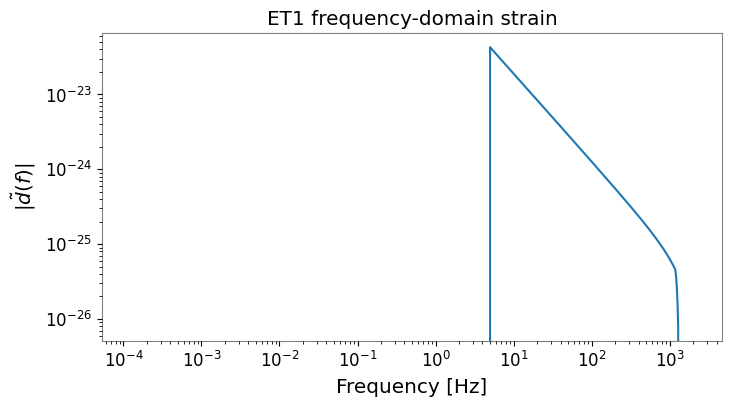

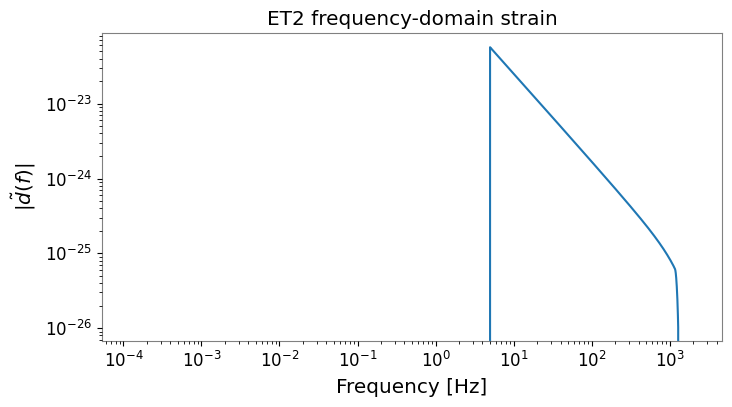

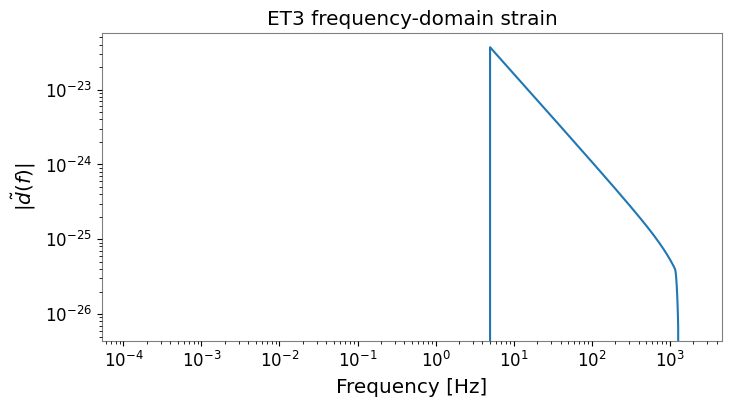

In [27]:
import matplotlib.pyplot as plt
for ifo in ifos:
    plt.figure(figsize=(8, 4))
    plt.loglog(ifo.data.frequencies, np.abs(ifo.data.fd))
    plt.title(f"{ifo.name} frequency-domain strain")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel(r"$|\tilde{d}(f)|$")
    plt.grid()
    plt.show()

--- Waveform model ---

--- Prior ---

In [28]:
M_c_min, M_c_max = 1.18, 1.21
q_min, q_max = 0.5, 1.0

#d_L_min, d_L_max = 30.0, 50.0
#t_det_min, t_det_max = -0.001, 0.001
t_c_min, t_c_max = -0.001, 0.001

s1_z_min, s1_z_max = -0.05, 0.05
s2_z_min, s2_z_max = -0.05, 0.05

dL_mu, dL_sigma = 100.0, 4.72      # adjust to your intended constraint width
iota_mu, iota_sigma = 2.62, 0.06   # see note on sigma below
psi_mu, psi_sigma = 3.14, 0.2
# --- PPE prior ranges, from Table I of Imam & Lagos (arXiv:2604.24526),
# l=|m|=2 ("Set 1"/"Set 2") case ---
alpha_min, alpha_max = -1e-2, 1e-2
beta_min, beta_max = -1e-4, 1e-4
alphaB_min, alphaB_max = -5.0, 5.0


prior = CombinePrior(
    [
        UniformPrior(M_c_min, M_c_max, parameter_names=["M_c"]),
        UniformPrior(q_min, q_max, parameter_names=["q"]),

        UniformPrior(s1_z_min, s1_z_max, parameter_names=["s1_z"]),
        UniformPrior(s2_z_min, s2_z_max, parameter_names=["s2_z"]),

        #SinePrior(parameter_names=["iota"]),

         #PowerLawPrior(d_L_min, d_L_max, 2.0, parameter_names=["d_L"]),
         GaussianPrior(dL_mu, dL_sigma, parameter_names=["d_L"]),
         GaussianPrior(iota_mu, iota_sigma, parameter_names=["iota"]),
         #UniformPrior(t_det_min, t_det_max, parameter_names=["t_det"]),
        UniformPrior(t_c_min, t_c_max, parameter_names=["t_c"]),
        GaussianPrior(psi_mu, psi_sigma, parameter_names=["psi"]),
        # UniformPrior(0.0, 2 * jnp.pi, parameter_names=["ra"]),
        # CosinePrior(parameter_names=["dec"]),

        UniformPrior(0.0, 2 * jnp.pi, parameter_names=["phase_c"]),
        UniformPrior(0.0, 5000.0, parameter_names=["lambda_1"]),
        UniformPrior(0.0, 5000.0, parameter_names=["lambda_2"]),

        # --- PPE (non-GR) parameters ---
        UniformPrior(alpha_min, alpha_max, parameter_names=["alpha"]),
        UniformPrior(beta_min, beta_max, parameter_names=["beta"]),
        UniformPrior(alphaB_min, alphaB_max, parameter_names=["alphaB"]),
    ]
)


In [29]:
prior

Combine(priors=(UniformPrior(xmin=1.18, xmax=1.21, parameter_names=('M_c',)), UniformPrior(xmin=0.5, xmax=1.0, parameter_names=('q',)), UniformPrior(xmin=-0.05, xmax=0.05, parameter_names=('s1_z',)), UniformPrior(xmin=-0.05, xmax=0.05, parameter_names=('s2_z',)), GaussianPrior(mu=100.0, sigma=4.72, parameter_names=('d_L',)), GaussianPrior(mu=2.62, sigma=0.06, parameter_names=('iota',)), UniformPrior(xmin=-0.001, xmax=0.001, parameter_names=('t_c',)), GaussianPrior(mu=3.14, sigma=0.2, parameter_names=('psi',)), UniformPrior(xmin=0.0, xmax=6.283185307179586, parameter_names=('phase_c',)), UniformPrior(xmin=0.0, xmax=5000.0, parameter_names=('lambda_1',)), UniformPrior(xmin=0.0, xmax=5000.0, parameter_names=('lambda_2',)), UniformPrior(xmin=-0.01, xmax=0.01, parameter_names=('alpha',)), UniformPrior(xmin=-0.0001, xmax=0.0001, parameter_names=('beta',)), UniformPrior(xmin=-5.0, xmax=5.0, parameter_names=('alphaB',))), parameter_names=('M_c', 'q', 's1_z', 's2_z', 'd_L', 'iota', 't_c', 'psi'

In [30]:
# !pip install --upgrade equinox

In [31]:
import jax.numpy as jnp
from jimgw.core.transforms import BijectiveTransform
from jax.scipy.special import erf, erfinv

def norm_cdf(z):
    return 0.5 * (1 + erf(z / jnp.sqrt(2)))

def norm_ppf(p):
    return jnp.sqrt(2) * erfinv(2 * p - 1)

class GaussianQuantileTransform(BijectiveTransform):
    """Natural direction: unit cube -> Gaussian(mu, sigma), same convention as PowerLawTransform."""
    def __init__(self, name_mapping, mu, sigma):
        super().__init__(name_mapping)
        self.mu = mu
        self.sigma = sigma
        self.transform_func = self._forward
        self.inverse_transform_func = self._inverse

    def _forward(self, params):
        # unit-cube -> physical
        u = params[self.name_mapping[0][0]]
        x = self.mu + self.sigma * norm_ppf(u)
        return {self.name_mapping[1][0]: x}

    def _inverse(self, params):
        # physical -> unit-cube
        x = params[self.name_mapping[1][0]]
        u = norm_cdf((x - self.mu) / self.sigma)
        return {self.name_mapping[0][0]: u}

--- Transforms ---

Each parameter is mapped to [0, 1].  Transform patterns:
  Uniform [a, b]           → BoundToBound([a, b] → [0, 1])
  SinePrior  [0, π]        → CosineTransform → BoundToBound([-1, 1] → [0, 1])
  PowerLawPrior (α=2)      → reverse_bijective_transform(PowerLawTransform)

In [32]:
sample_transforms = [
    # SkyFrameToDetectorFrameSkyPositionTransform(trigger_time=gps, ifos=ifos),

    BoundToBound(
        name_mapping=(["M_c"], ["M_c_unit"]),
        original_lower_bound=M_c_min,
        original_upper_bound=M_c_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),

    BoundToBound(
        name_mapping=(["q"], ["q_unit"]),
        original_lower_bound=q_min,
        original_upper_bound=q_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),

    BoundToBound(
        name_mapping=(["s1_z"], ["s1_z_unit"]),
        original_lower_bound=s1_z_min,
        original_upper_bound=s1_z_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),

    BoundToBound(
        name_mapping=(["s2_z"], ["s2_z_unit"]),
        original_lower_bound=s2_z_min,
        original_upper_bound=s2_z_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),
    reverse_bijective_transform(GaussianQuantileTransform(name_mapping=(["d_L_unit"], ["d_L"]), mu=dL_mu, sigma=dL_sigma)),
    reverse_bijective_transform(GaussianQuantileTransform(name_mapping=(["iota_unit"], ["iota"]), mu=iota_mu, sigma=iota_sigma)),
    reverse_bijective_transform(GaussianQuantileTransform(name_mapping=(["psi_unit"], ["psi"]), mu=psi_mu, sigma=psi_sigma)),

    # CosineTransform(name_mapping=(["iota"], ["cos_iota"])),

    # BoundToBound(
    #     name_mapping=(["cos_iota"], ["cos_iota_unit"]),
    #     original_lower_bound=-1.0,
    #     original_upper_bound=1.0,
    #     target_lower_bound=0.0,
    #     target_upper_bound=1.0,
    # ),

    # reverse_bijective_transform(
    #     PowerLawTransform(
    #         name_mapping=(["d_L_unit"], ["d_L"]),
    #         xmin=d_L_min,
    #         xmax=d_L_max,
    #         alpha=2.0,
    #     )
    # ),

    # BoundToBound(
    #     name_mapping=(["t_det"], ["t_det_unit"]),
    #     original_lower_bound=t_det_min,
    #     original_upper_bound=t_det_max,
    #     target_lower_bound=0.0,
    #     target_upper_bound=1.0,
    # ),
    BoundToBound(name_mapping=(["t_c"], ["t_c_unit"]),
                 original_lower_bound=t_c_min,
                 original_upper_bound=t_c_max,
                 target_lower_bound=0.0,
                 target_upper_bound=1.0),
    # BoundToBound(
    #     name_mapping=(["psi"], ["psi_unit"]),
    #     original_lower_bound=0.0,
    #     original_upper_bound=jnp.pi,
    #     target_lower_bound=0.0,
    #     target_upper_bound=1.0,
    # ),
    BoundToBound(
        name_mapping=(["phase_c"], ["phase_c_unit"]),
        original_lower_bound=0.0,
        original_upper_bound=2*jnp.pi,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),
     # --- Tidal deformability ---
    BoundToBound(name_mapping=(["lambda_1"], ["lambda_1_unit"]),
             original_lower_bound=0.0, original_upper_bound=5000.0,
             target_lower_bound=0.0, target_upper_bound=1.0),
    BoundToBound(name_mapping=(["lambda_2"], ["lambda_2_unit"]),
             original_lower_bound=0.0, original_upper_bound=5000.0,
             target_lower_bound=0.0, target_upper_bound=1.0),

    # --- PPE (non-GR) parameters ---
    BoundToBound(
        name_mapping=(["alpha"], ["alpha_unit"]),
        original_lower_bound=alpha_min,
        original_upper_bound=alpha_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),
    BoundToBound(
        name_mapping=(["beta"], ["beta_unit"]),
        original_lower_bound=beta_min,
        original_upper_bound=beta_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),
    BoundToBound(
        name_mapping=(["alphaB"], ["alphaB_unit"]),
        original_lower_bound=alphaB_min,
        original_upper_bound=alphaB_max,
        target_lower_bound=0.0,
        target_upper_bound=1.0,
    ),

    # BoundToBound(
    #     name_mapping=(["azimuth"], ["azimuth_unit"]),
    #     original_lower_bound=0.0,
    #     original_upper_bound=2 * jnp.pi,
    #     target_lower_bound=0.0,
    #     target_upper_bound=1.0,
    # ),

    # CosineTransform(name_mapping=(["zenith"], ["cos_zenith"])),

    # BoundToBound(
    #     name_mapping=(["cos_zenith"], ["cos_zenith_unit"]),
    #     original_lower_bound=-1.0,
    #     original_upper_bound=1.0,
    #     target_lower_bound=0.0,
    #     target_upper_bound=1.0,
    # ),
]


In [33]:
likelihood_transforms =[
    MassRatioToSymmetricMassRatioTransform,
    # reverse_bijective_transform(
    #     GeocentricArrivalTimeToDetectorArrivalTimeTransform(
    #         trigger_time=gps, ifo=ifos[0]
    #     )
    # ),
]

In [34]:
import jimgw
import jimgw.samplers
import os

print(jimgw.samplers.__path__)

['/usr/local/lib/python3.13/dist-packages/jimgw/samplers']


In [35]:
ls -R /usr/local/lib/python3.12/dist-packages/jimgw/samplers

ls: cannot access '/usr/local/lib/python3.12/dist-packages/jimgw/samplers': No such file or directory


In [36]:
# import inspect
# from jimgw.core.jim import Jim
# from jimgw.core.single_event.likelihood import TransientLikelihoodFD

# print(inspect.getsource(Jim._validate_problem))   # see exactly what "provided" is computed from
# print(inspect.signature(TransientLikelihoodFD.__init__))

In [37]:
 # confirm all 7 keys are actually there before building Jim

--- Likelihood ---

In [38]:
# likelihood = TransientLikelihoodFD(
#     ifos,
#     waveform=waveform,
#     trigger_time=gps,
#     f_min=fmin,
#     f_max=fmax,
#     phase_marginalization=True,
# )



In [39]:
fixed_parameters = {
    "ra": inj_params["ra"],
    "dec": inj_params["dec"],
}

# likelihood = TransientLikelihoodFD(
#     ifos,
#     waveform=waveform,
#     trigger_time=gps,
#     f_min=fmin,
#     f_max=fmax,
#     #phase_marginalization=True,
#     fixed_parameters=fixed_parameters,

# )

In [40]:
import jax.numpy as jnp
from jimgw.core.single_event.likelihood import HeterodynedTransientLikelihoodFD

def _compute_coefficients_sparse(data, h_ref, psd, freqs, f_bins, f_bins_center):
    df = freqs[1] - freqs[0]
    data_prod = jnp.array(data * h_ref.conj()) / psd
    self_prod = jnp.array(h_ref * h_ref.conj()) / psd
    n_bins = f_bins_center.shape[0]
    bin_idx = jnp.clip(jnp.searchsorted(f_bins, freqs, side="right") - 1, 0, n_bins - 1)
    bin_idx = jnp.where(freqs == f_bins[-1], n_bins - 1, bin_idx)
    freq_shift = freqs - f_bins_center[bin_idx]

    def scatter_sum(values):
        return jnp.zeros((n_bins,), dtype=values.dtype).at[bin_idx].add(values)

    A0_array = 4 * scatter_sum(data_prod) * df
    A1_array = 4 * scatter_sum(data_prod * freq_shift) * df
    B0_array = 4 * scatter_sum(self_prod) * df
    B1_array = 4 * scatter_sum(self_prod * freq_shift) * df
    return A0_array, A1_array, B0_array, B1_array

HeterodynedTransientLikelihoodFD.compute_coefficients = staticmethod(_compute_coefficients_sparse)

In [41]:
import jax.numpy as jnp

def _isin_sparse(element, test_elements, **kwargs):
    """Drop-in replacement for jnp.isin(element, test_elements) when `element`
    is sorted and `test_elements` is an exact subset of it (true here, since
    self.frequencies is built as the union of all detectors' frequency grids).
    O(n) memory instead of O(len(element) * len(test_elements))."""
    element = jnp.asarray(element)
    test_elements = jnp.asarray(test_elements)
    idx = jnp.searchsorted(element, test_elements)
    idx = jnp.clip(idx, 0, element.shape[0] - 1)
    return jnp.zeros(element.shape[0], dtype=bool).at[idx].set(True)

jnp.isin = _isin_sparse

In [42]:
likelihood_het = HeterodynedTransientLikelihoodFD(
    ifos, waveform=waveform, trigger_time=gps, f_min=fmin, f_max=fmax,
    fixed_parameters=fixed_parameters,
    reference_parameters=inj_params,   # or the posterior median, either is reasonable here
   # phase_marginalization=True,
)


INFO | jimgw.core.single_event.likelihood | Initializing heterodyned likelihood..
INFO | jimgw.core.single_event.likelihood | Reference parameters provided, which are {'M_c': 1.1975174, 'eta': 0.2379, 's1_z': 0.028327, 's2_z': 0.013249, 'd_L': 100.0, 't_c': -0.000236, 'phase_c': 2.0, 'iota': 2.62, 'psi': 3.14, 'ra': 3.4396, 'dec': -0.3998, 'lambda_1': 791.04366468, 'lambda_2': 891.04366468, 'alpha': 0.0, 'beta': 0.0, 'alphaB': 0.0}
INFO | jimgw.core.single_event.likelihood | Constructing reference waveforms..


--- Sample ---

In [43]:
SEED = 1

jim = Jim(
    #likelihood,
    likelihood_het,
    prior,
    sample_transforms=sample_transforms,
    likelihood_transforms=likelihood_transforms,
   # periodic=["psi_unit", "azimuth_unit"],
    periodic=["phase_c_unit"],
    sampler_config=BlackJAXNSAWConfig(
        n_live=2000,
        n_delete_frac=0.25,
        n_target=80,
    ),
)

INFO | jimgw.core.jim | Using sample transforms.


In [44]:

jim._rng_key, jim._sampler_key = jax.random.split(jax.random.key(SEED), 2)

In [45]:
print("SEED =", SEED)
print("rng key:", jim._rng_key)
print("sampler key:", jim._sampler_key)

# If you want to see the raw uint32 values:
print("rng key data:", jax.random.key_data(jim._rng_key))
print("sampler key data:", jax.random.key_data(jim._sampler_key))

SEED = 1
rng key: Array((), dtype=key<fry>) overlaying:
[ 507451445 1853169794]
sampler key: Array((), dtype=key<fry>) overlaying:
[1948878966 4237131848]
rng key data: [ 507451445 1853169794]
sampler key data: [1948878966 4237131848]


#Sample

In [46]:

start_time = time.time()
jim.sample()
end_time = time.time()
print(f"Sampling took {(end_time - start_time) / 60:.2f} mins")

Sampling took 100.81 mins


In [47]:
inj_full = dict(inj_params)
logL_at_injection = likelihood_het.evaluate(inj_full)
print("logL at injection:", logL_at_injection)

chains = jim.get_samples()
print("max logL sampler:", np.max(chains["log_likelihood"]))

logL at injection: 110914.19909048172
max logL sampler: 110913.51229740988


In [48]:
import os
import numpy as np
import jax

# -----------------------------
# Samples
# -----------------------------
samples = jim.get_samples()
samples = {k: np.asarray(v) for k, v in samples.items()}

# -----------------------------
# Diagnostics
# -----------------------------
diagnostics = jim.get_diagnostics()

# -----------------------------
# RNG keys
# -----------------------------
rng_key = jax.random.key_data(jim._rng_key)
sampler_key = jax.random.key_data(jim._sampler_key)

# -----------------------------
# Automatic filename
# -----------------------------
filename = (
    f"xasnrtidalv3_freespins_Representative_all_HK_iota_psi_gaussian+sigma=0.06_0.2_PPE_tidal_duration={int(duration)}_ET_ZN_Het_gauss_dl_iota_Nested_fmax=2048_nlive=2000_phic_Injection_NSAW_"
    f"rng_{rng_key[0]}_{rng_key[1]}_"
    f"logZ_{diagnostics['log_Z']:.2f}.npz"
)

counter = 1
base = filename[:-4]
while os.path.exists(filename):
    filename = f"{base}_{counter}.npz"
    counter += 1

# -----------------------------
# Save everything
# -----------------------------
np.savez_compressed(
    filename,
    **samples,
    rng_key=rng_key,
    sampler_key=sampler_key,
    logZ=diagnostics["log_Z"],
    logZ_error=diagnostics["log_Z_error"],
    n_likelihood_evaluations=diagnostics["n_likelihood_evaluations"],
)

print(f"Saved to: {filename}")

Saved to: xasnrtidalv3_freespins_Representative_all_HK_iota_psi_gaussian+sigma=0.06_0.2_PPE_tidal_duration=8192_ET_ZN_Het_gauss_dl_iota_Nested_fmax=2048_nlive=2000_phic_Injection_NSAW_rng_3704974950_1863054868_logZ_110845.59.npz


In [49]:
print("logZ:", diagnostics["log_Z"], diagnostics["log_Z_error"])
print("max logL:", np.max(samples["log_likelihood"]))
print("median logL:", np.median(samples["log_likelihood"]))

logZ: 110845.58995031826 0.19053056770808702
max logL: 110913.51229740988
median logL: 110909.4021582418


In [50]:
print(jim.__dict__.keys())

dict_keys(['likelihood', 'prior', 'sample_transforms', 'likelihood_transforms', 'parameter_names', '_log_prior_fn', '_log_likelihood_fn', '_log_posterior_fn', '_rng_key', '_sampler_key', '_sampler_config', 'sampler'])


In [51]:
print(jim._rng_key)
print(jim._sampler_key)

Array((), dtype=key<fry>) overlaying:
[3704974950 1863054868]
Array((), dtype=key<fry>) overlaying:
[1948878966 4237131848]


--- Results ---

In [52]:
diagnostics = jim.get_diagnostics()
print(f"log Z = {diagnostics['log_Z']:.2f} ± {diagnostics['log_Z_error']:.2f}")
print(f"Likelihood evaluations: {diagnostics['n_likelihood_evaluations']:,}")

log Z = 110845.59 ± 0.20
Likelihood evaluations: 161,535,025


In [53]:
import jax
import numpy as np

chains = jim.get_samples()


q_inj (from injected eta): 0.639344262295082


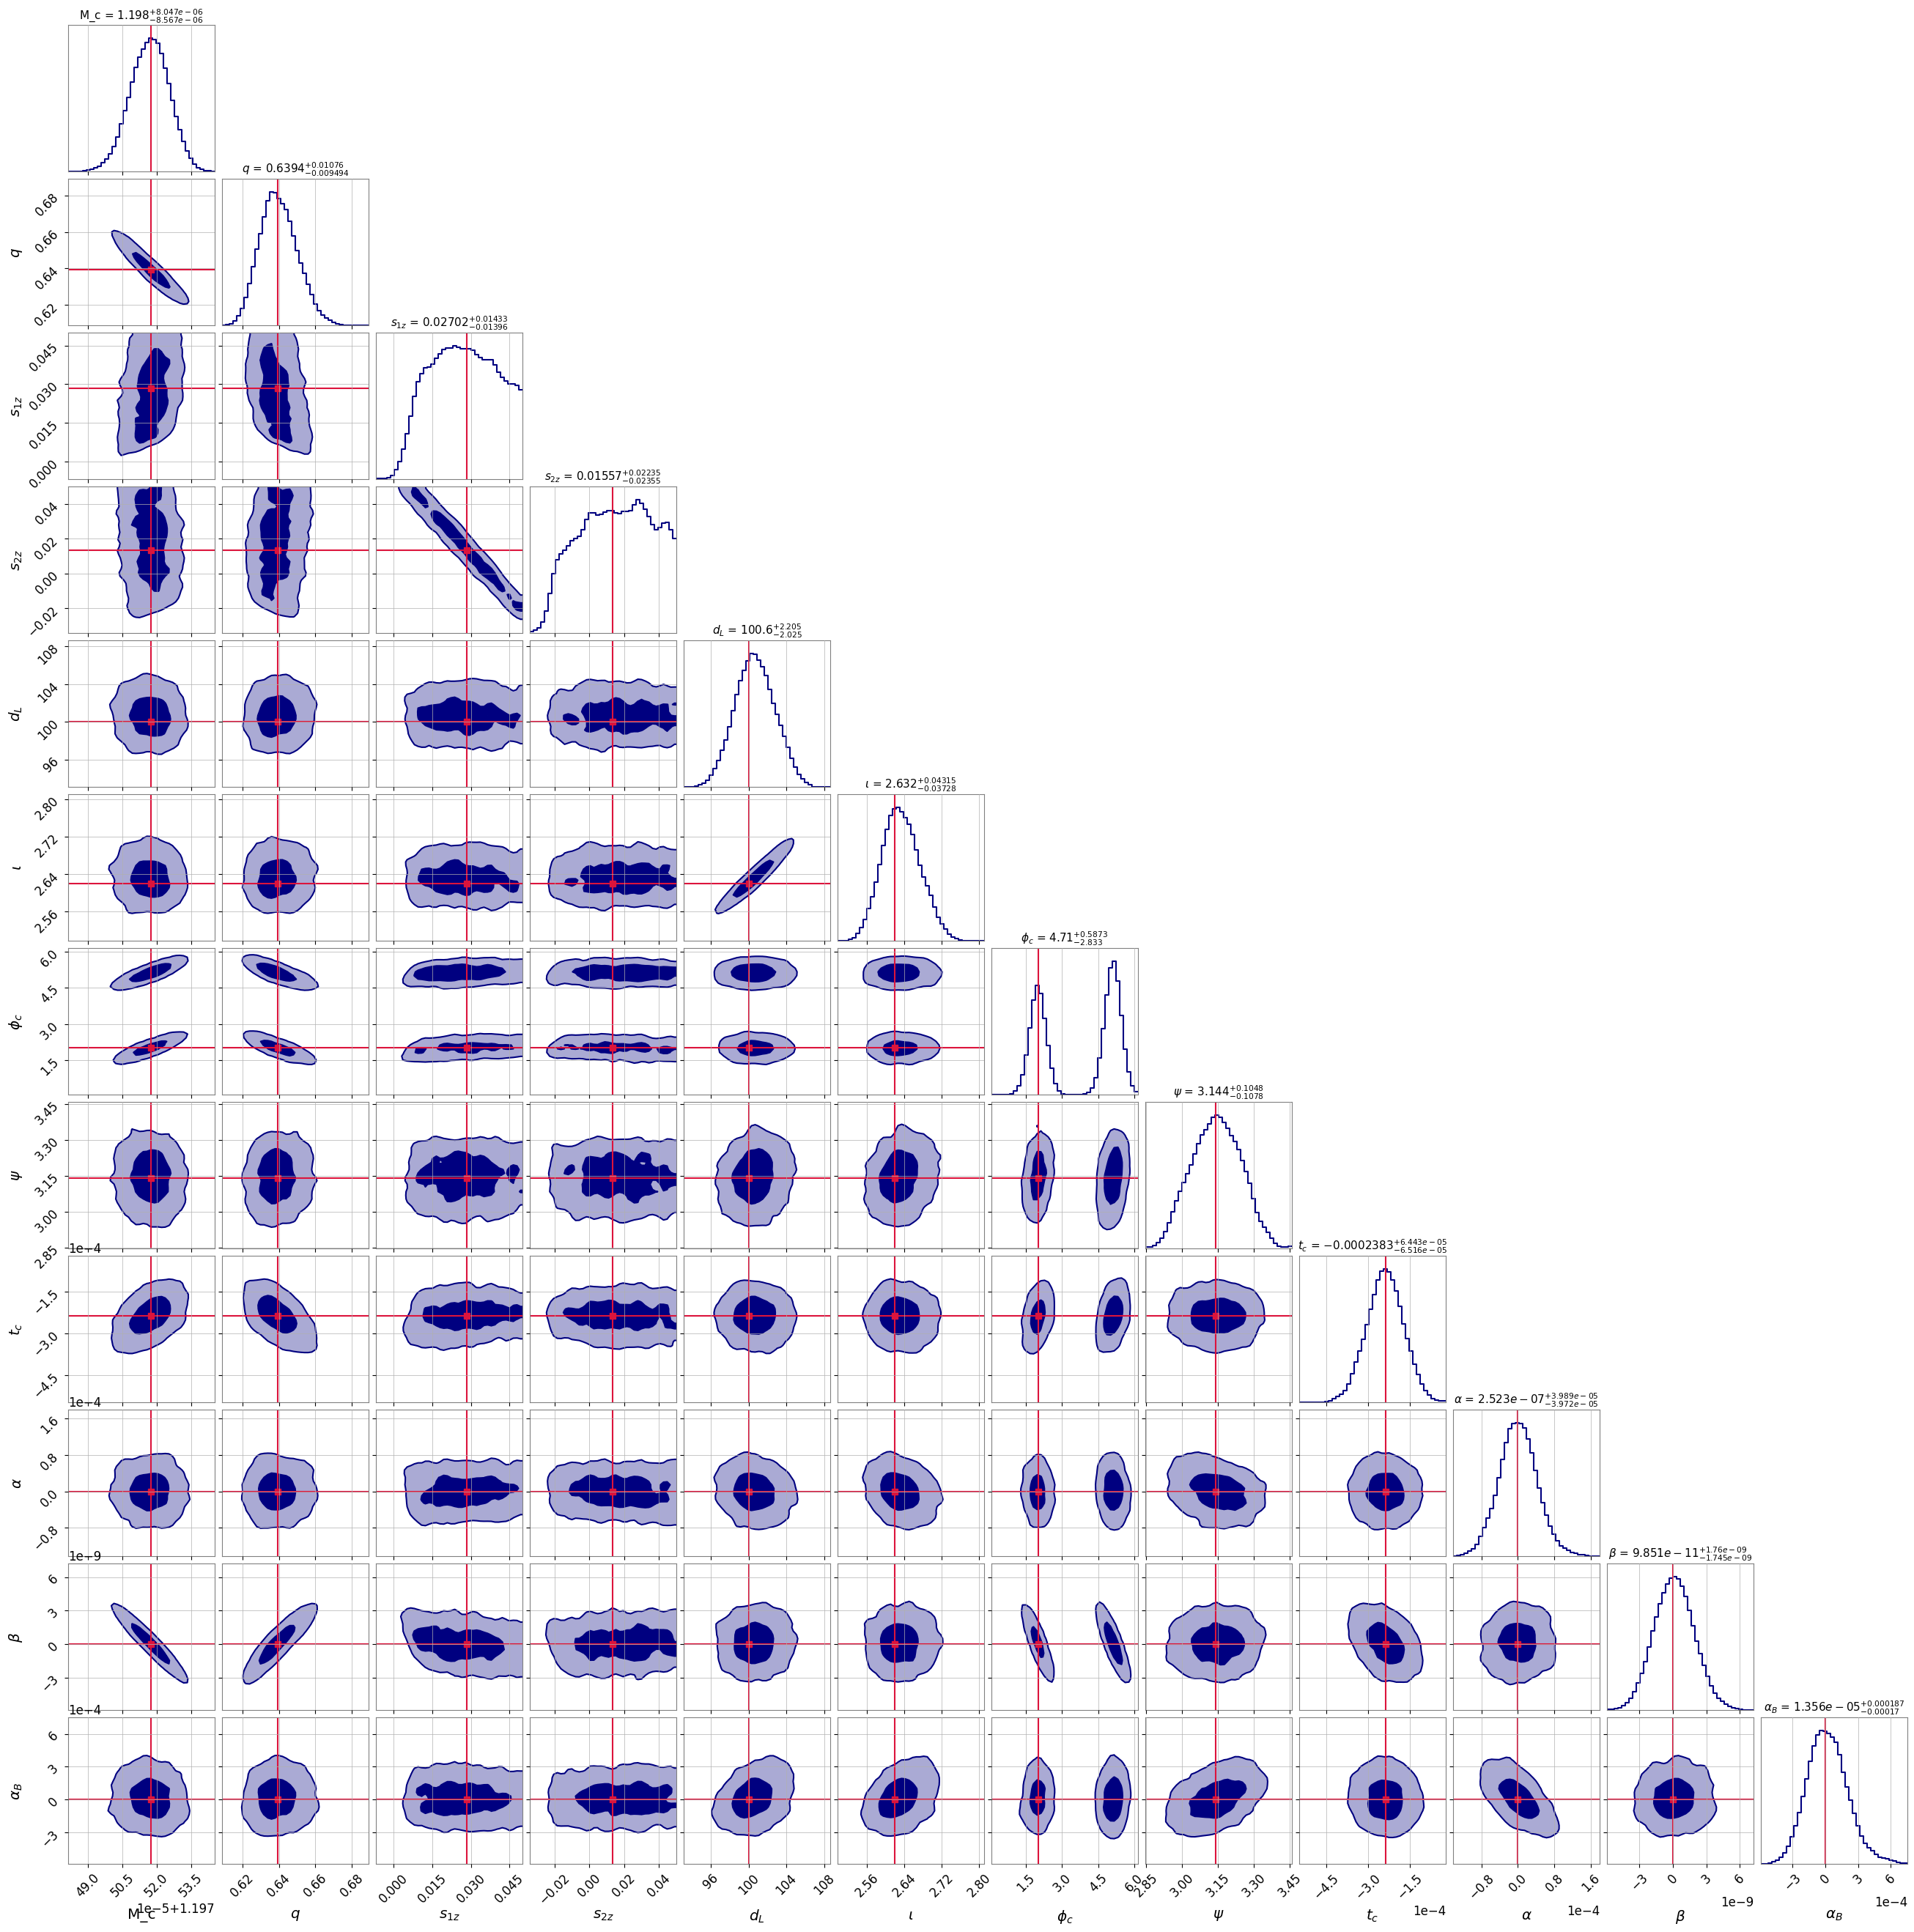

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import corner

def eta_to_q(eta):
    """Invert eta = q/(1+q)^2 for q in (0,1]."""
    return ((1 - 2*eta) - np.sqrt(1 - 4*eta)) / (2*eta)

q_inj = eta_to_q(inj_params["eta"])
print("q_inj (from injected eta):", q_inj)   # ~0.639, not 0.8

chains = jim.get_samples()

# alpha/beta/alphaB removed: this is the sanity-check run where they are
# fixed at 0.0 (not sampled -- see cell 32/38/49), so they no longer exist
# as keys in chains = jim.get_samples(). Including them here would KeyError.
# alpha/beta/alphaB are free/sampled in this run (see cell 32/38/49), so
# include them here to actually see their recovered posteriors.
params = ["M_c","q", "s1_z", "s2_z","d_L","iota","phase_c","psi","t_c","alpha","beta","alphaB"]
labels = [
   r"M_c", r"$q$", r"$s_{1z}$", r"$s_{2z}$",r"$d_L$",r"$\iota$",r"$\phi_c$",r"$\psi$",r"$t_c$",
   r"$\alpha$", r"$\beta$", r"$\alpha_B$",
]
truths = [
    inj_params["M_c"],
    q_inj,
    inj_params["s1_z"],
    inj_params["s2_z"],
    inj_params["d_L"],
    inj_params["iota"],
    inj_params["phase_c"],
    inj_params["psi"],
    inj_params["t_c"],
    inj_params["alpha"],
    inj_params["beta"],
    inj_params["alphaB"],
]

samples = np.vstack([np.asarray(chains[p]) for p in params]).T

level_1sigma = 0.39346934
level_2sigma = 0.86466472
fig = corner.corner(
    samples,
    labels=labels,
    truths=truths,
    truth_color="crimson",
    levels=(level_1sigma, level_2sigma),
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    color="navy",
    hist_kwargs={"color": "navy", "linewidth": 1.5},
    truth_kwargs={"color": "crimson", "linewidth": 1.8, "linestyle": "--"},
    show_titles=True,
    title_fmt=".4g",
    title_kwargs={"fontsize": 11},
    smooth=1.0,
    smooth1d=1.0,
    bins=40,
)
plt.savefig(f"Representative_all_HK_iota_psi_gaussian+sigma=0.06_0.2_PPE_tidal_duration={int(duration)}_IMRPHENOMD_ET_ZN_Het_gauss_dl_iota_nlive=500_phic_corner_injection_1sigma_2sigma.png", dpi=300, bbox_inches="tight")
plt.show()


In [55]:
truths

[1.1975174,
 np.float64(0.639344262295082),
 0.028327,
 0.013249,
 100.0,
 2.62,
 2.0,
 3.14,
 -0.000236,
 0.0,
 0.0,
 0.0]

In [56]:
import numpy as np

# alpha/beta/alphaB removed: fixed at 0.0 in this sanity-check run, no
# longer present in chains = jim.get_samples().
# alpha/beta/alphaB are free/sampled in this run -- include them.
params = ["M_c", "q", "s1_z", "s2_z","d_L","iota","phase_c","psi","t_c","alpha","beta","alphaB"]

for p in params:
    x = np.asarray(chains[p])
    median = np.median(x)
    std = np.std(x, ddof=1)   # sample standard deviation
    print(f"{p:8s} median = {median:.6g}, std = {std:.6g}")


M_c      median = 1.19752, std = 8.294e-06
q        median = 0.63936, std = 0.0101038
s1_z     median = 0.0270174, std = 0.0124013
s2_z     median = 0.0155682, std = 0.0200101
d_L      median = 100.638, std = 2.07854
iota     median = 2.63164, std = 0.0398736
phase_c  median = 4.7103, std = 1.59092
psi      median = 3.14351, std = 0.101203
t_c      median = -0.000238282, std = 6.56862e-05
alpha    median = 2.52314e-07, std = 4.12856e-05
beta     median = 9.85141e-11, std = 1.77012e-09
alphaB   median = 1.35554e-05, std = 0.000184394


In [57]:
for p, inj in [
    ("M_c", inj_params["M_c"]),
    ("q", q_inj),
    ("s1_z", inj_params["s1_z"]),
    ("s2_z", inj_params["s2_z"]),
    ("d_L", inj_params["d_L"]),
    ("iota", inj_params["iota"]),
    ("phase_c", inj_params["phase_c"]),
    ("psi", inj_params["psi"]),
    ("t_c", inj_params["t_c"]),
    # alpha/beta/alphaB are free/sampled in this run -- include them.
    ("alpha", inj_params["alpha"]),
    ("beta", inj_params["beta"]),
    ("alphaB", inj_params["alphaB"]),
]:
    x = np.asarray(chains[p])
    perc = 100 * np.mean(x < inj)
    print(f"{p:6s}: injected value at {perc:.1f} percentile")


M_c   : injected value at 50.8 percentile
q     : injected value at 49.9 percentile
s1_z  : injected value at 53.3 percentile
s2_z  : injected value at 46.2 percentile
d_L   : injected value at 37.9 percentile
iota  : injected value at 38.1 percentile
phase_c: injected value at 23.2 percentile
psi   : injected value at 48.7 percentile
t_c   : injected value at 51.6 percentile
alpha : injected value at 49.8 percentile
beta  : injected value at 47.9 percentile
alphaB: injected value at 47.1 percentile


In [58]:
frequencies = ifos[0].data.frequencies

In [59]:
h_inj = waveform(frequencies, inj_params)   # inj_params already has 'eta' directly

median_params = dict(fixed_parameters)   # everything currently fixed, physical values

if "M_c" in chains:
    median_params["M_c"] = float(np.median(chains["M_c"]))
if "q" in chains:
    q_med = float(np.median(chains["q"]))
    median_params["eta"] = q_med / (1 + q_med) ** 2
if "s1_z" in chains:
    median_params["s1_z"] = float(np.median(chains["s1_z"]))
if "s2_z" in chains:
    median_params["s2_z"] = float(np.median(chains["s2_z"]))
if "d_L" in chains:
    median_params["d_L"] = float(np.median(chains["d_L"]))
if "iota" in chains:
    median_params["iota"] = float(np.median(chains["iota"]))
if "phase_c" in chains:
    median_params["phase_c"] = float(np.median(chains["phase_c"]))
else:
    median_params["phase_c"] = 0.0
# --- PPE (non-GR) parameters ---
median_params["alpha"] = float(np.median(chains["alpha"])) if "alpha" in chains else 0.0
median_params["beta"] = float(np.median(chains["beta"])) if "beta" in chains else 0.0
median_params["alphaB"] = float(np.median(chains["alphaB"])) if "alphaB" in chains else 0.0

h_med = waveform(frequencies, median_params)


KeyError: 'lambda_1'

--- Breathing-mode (scalar polarization) diagnostic ---

In [ ]:
# Compare the recovered (median) breathing-mode amplitude against the tensor
# polarizations, and against the injected values, as a function of frequency.
plt.figure(figsize=(7, 5))
plt.loglog(frequencies, np.abs(h_inj["p"]), label="Injection $h_+$", alpha=0.7)
plt.loglog(frequencies, np.abs(h_inj["b"]), label="Injection $h_b$ (breathing)", alpha=0.7)
plt.loglog(frequencies, np.abs(h_med["p"]), "--", label="Posterior median $h_+$")
plt.loglog(frequencies, np.abs(h_med["b"]), "--", label="Posterior median $h_b$ (breathing)")
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|h(f)|$")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Tensor vs. breathing-mode amplitude")
plt.show()

inj_alphaB = inj_params["alphaB"]
med_alphaB = median_params["alphaB"]
print(f"alphaB injected = {inj_alphaB:.4g}, alphaB posterior median = {med_alphaB:.4g}")


In [ ]:
plt.figure(figsize=(7,5))

plt.loglog(frequencies, np.abs(h_inj["p"]), label="Injection plus")
plt.loglog(frequencies, np.abs(h_med["p"]), "--", label="Posterior median plus")

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|h_+(f)|$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(7,5))

plt.loglog(frequencies, np.abs(h_inj["c"]), label="Injection cross")
plt.loglog(frequencies, np.abs(h_med["c"]), "--", label="Posterior median cross")

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|h_\times(f)|$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
psi_inj = inj_params["psi"]
phase_c_inj = inj_params["phase_c"]
phase_c_alt = phase_c_inj + np.pi
psi_tol = 0.1  # radians
mask = np.abs(np.asarray(chains["psi"]) - psi_inj) < psi_tol
phase_c_near_psi_inj = np.asarray(chains["phase_c"])[mask]

plt.hist(phase_c_near_psi_inj, bins=40)
plt.axvline(phase_c_inj, color="r", label="inj")
plt.axvline(phase_c_alt, color="g", linestyle="--", label="inj + π (mod 2π)")
plt.legend()
plt.title(f"phase_c conditioned on psi near injection (n={mask.sum()})")
plt.show()

In [ ]:
# import jax
# import jax.numpy as jnp
# import numpy as np

# samples = chains
# samples = {k: np.asarray(v) for k, v in samples.items()}
# n_check = 50
# idx = np.random.choice(len(samples["M_c"]), n_check, replace=False)

# def mass_ratio_to_eta(q):
#     return q / (1 + q) ** 2

# p_batch = {k: jnp.asarray(v[idx]) for k, v in samples.items() if k not in ("log_likelihood", "log_prior", "q")}
# p_batch["eta"] = mass_ratio_to_eta(jnp.asarray(samples["q"][idx]))
# for k, v in fixed_parameters.items():
#     p_batch[k] = jnp.full(n_check, v)  # broadcast fixed params to match batch dim

# eval_full_jit = jax.jit(jax.vmap(likelihood.evaluate))
# eval_het_jit = jax.jit(jax.vmap(likelihood_het.evaluate))

# logL_full = eval_full_jit(p_batch)
# logL_het = eval_het_jit(p_batch)

# diffs = np.asarray(logL_full) - np.asarray(logL_het)
# print("max |diff|:", np.abs(diffs).max(), " mean:", diffs.mean(), " std:", diffs.std())

In [ ]:
import jimgw.core.prior as prior_module
print([x for x in dir(prior_module) if any(s in x for s in ("Gauss", "Normal", "Truncated"))])

In [ ]:
import inspect
from jimgw.core.prior import GaussianPrior, StandardNormalDistribution

print(inspect.getsource(GaussianPrior))
print("=" * 80)
print(inspect.getsource(StandardNormalDistribution))